In [1]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import matplotlib.pyplot as plt

DOSSIER = "/content/drive/MyDrive/aeroguard"

Mounted at /content/drive


In [2]:
df = pd.read_parquet(f"{DOSSIER}/data/processed/ds01_dev.parquet")
print(df.shape)
print(list(df.columns))

(4906636, 33)
['unit', 'cycle', 'Fc', 'hs', 'alt', 'Mach', 'TRA', 'T2', 'T24', 'T30', 'T48', 'T50', 'P15', 'P2', 'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf', 'fan_eff_mod', 'fan_flow_mod', 'LPC_eff_mod', 'LPC_flow_mod', 'HPC_eff_mod', 'HPC_flow_mod', 'HPT_eff_mod', 'HPT_flow_mod', 'LPT_eff_mod', 'LPT_flow_mod', 'RUL']


In [3]:
vols = (df.groupby(["unit", "cycle"])
          .agg(hs=("hs", "first"),
               RUL=("RUL", "first"),
               Fc=("Fc", "first"),
               duree_s=("hs", "size"))      # nombre de secondes = durée du vol
          .reset_index())
print(vols.shape)
vols.head()

(553, 6)


,unit,cycle,hs,RUL,Fc,duree_s
0,1,1,1,99,1,4498
1,1,2,1,98,1,4660
2,1,3,1,97,1,5355
3,1,4,1,96,1,4181
4,1,5,1,95,1,4495


In [4]:
# 1) Le RUL est-il constant pendant un vol ?
nb_valeurs = df.groupby(["unit", "cycle"])["RUL"].nunique()
print("Max de valeurs RUL différentes dans un vol :", nb_valeurs.max())   # attendu : 1

# 2) cycle + RUL est-il constant par moteur ?
vols["cycle_plus_RUL"] = vols["cycle"] + vols["RUL"]
print(vols.groupby("unit")["cycle_plus_RUL"].agg(["min", "max"]))

# 3) Quel RUL au dernier vol ?
print(vols.groupby("unit")["RUL"].min())

Max de valeurs RUL différentes dans un vol : 1
      min  max
unit          
1     100  100
2      75   75
3     100  100
4      95   95
5      89   89
6      94   94
unit
1    0
2    0
3    0
4    0
5    0
6    0
Name: RUL, dtype: int32


In [5]:
# hs ne remonte jamais ? (1,1,1,0,0 = "décroissant")
print(vols.groupby("unit")["hs"].apply(lambda s: s.is_monotonic_decreasing))

# Premier vol en dégradation anormale de chaque moteur
debut_panne = vols[vols["hs"] == 0].groupby("unit")["cycle"].min()
print(debut_panne)

unit
1    True
2    True
3    True
4    True
5    True
6    True
Name: hs, dtype: bool
unit
1    37
2    19
3    26
4    38
5    19
6    25
Name: cycle, dtype: int32


In [6]:
colonnes_T = ["fan_eff_mod", "fan_flow_mod", "LPC_eff_mod", "LPC_flow_mod",
              "HPC_eff_mod", "HPC_flow_mod", "HPT_eff_mod", "HPT_flow_mod",
              "LPT_eff_mod", "LPT_flow_mod"]

T_vols = df.groupby(["unit", "cycle"])[colonnes_T].mean().reset_index()

# Premier vol vs dernier vol du moteur 1
moteur1 = T_vols[T_vols["unit"] == T_vols["unit"].min()]
print(moteur1[colonnes_T].iloc[[0, -1]].T)    # .T = tourner le tableau

                    0         99
fan_eff_mod   0.000000  0.000000
fan_flow_mod  0.000000  0.000000
LPC_eff_mod   0.000000  0.000000
LPC_flow_mod  0.000000  0.000000
HPC_eff_mod   0.000000  0.000000
HPC_flow_mod  0.000000  0.000000
HPT_eff_mod  -0.000604 -0.017206
HPT_flow_mod  0.000000  0.000000
LPT_eff_mod   0.000000  0.000000
LPT_flow_mod  0.000000  0.000000


In [8]:
import os

os.makedirs(f"{DOSSIER}/results/figures", exist_ok=True)
print("Dossier prêt :", os.path.exists(f"{DOSSIER}/results/figures"))

Dossier prêt : True


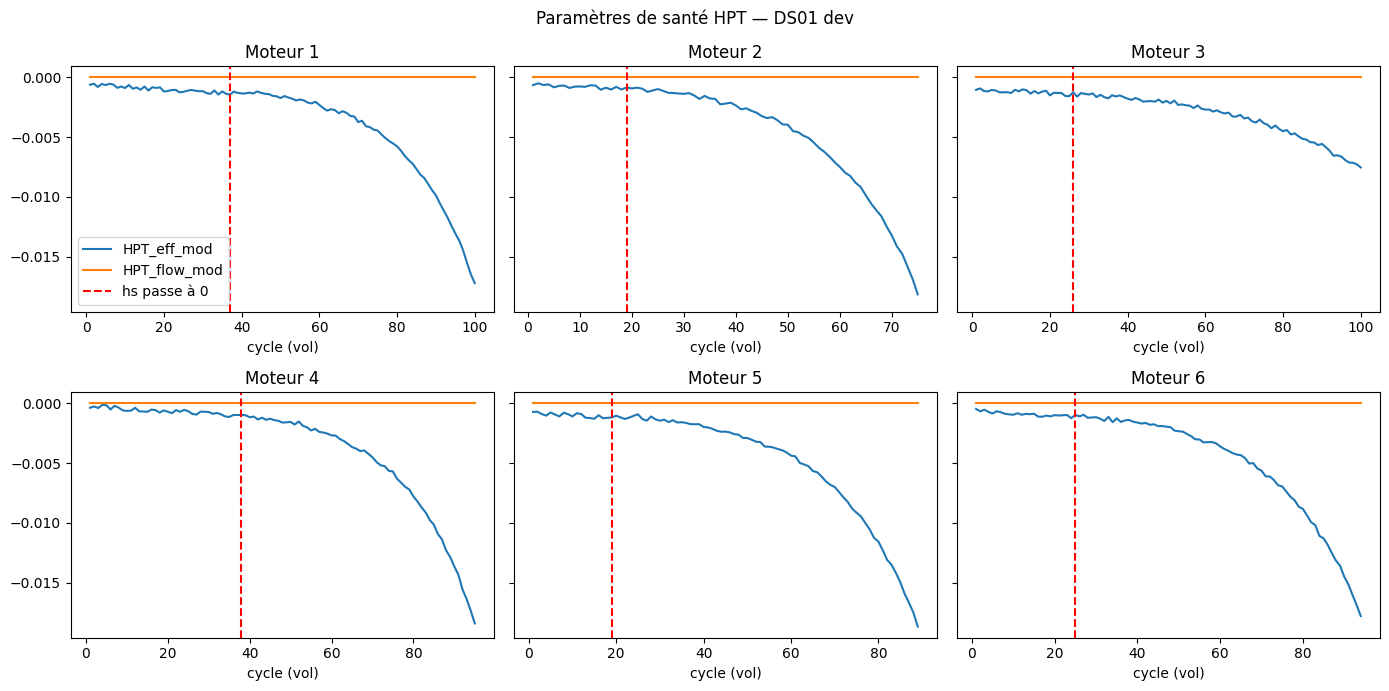

In [10]:
moteurs = T_vols["unit"].unique()
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)

for ax, u in zip(axes.flat, moteurs):
    m = T_vols[T_vols["unit"] == u]
    ax.plot(m["cycle"], m["HPT_eff_mod"], label="HPT_eff_mod")
    ax.plot(m["cycle"], m["HPT_flow_mod"], label="HPT_flow_mod")
    ax.axvline(debut_panne[u], color="red", linestyle="--", label="hs passe à 0")
    ax.set_title(f"Moteur {u}")
    ax.set_xlabel("cycle (vol)")

axes.flat[0].legend()
plt.suptitle("Paramètres de santé HPT — DS01 dev")
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/14_HPT_sante.png", dpi=120)
plt.show()

In [11]:
COMPOSANTS = ["fan", "LPC", "HPC", "HPT", "LPT"]

def composant_touche(ligne, seuil=1e-3):
    """Retourne le composant le plus dégradé ('fan', 'LPC', ...) ou 'aucun'.

    ligne : une ligne (Series) qui contient les 10 colonnes *_eff_mod / *_flow_mod.
    seuil : en dessous, on considère que rien n'est vraiment dégradé.
    """
    meilleur, pire_valeur = "aucun", seuil
    for c in COMPOSANTS:
        degradation = max(abs(ligne[f"{c}_eff_mod"]), abs(ligne[f"{c}_flow_mod"]))
        if degradation > pire_valeur:
            meilleur, pire_valeur = c, degradation
    return meilleur

# Appliquer au DERNIER vol de chaque moteur
derniers = T_vols.groupby("unit").tail(1)
for _, ligne in derniers.iterrows():
    print(f"Moteur {int(ligne['unit'])} → {composant_touche(ligne)}")

Moteur 1 → HPT
Moteur 2 → HPT
Moteur 3 → HPT
Moteur 4 → HPT
Moteur 5 → HPT
Moteur 6 → HPT


In [12]:
vols = vols.merge(T_vols[["unit", "cycle"] + colonnes_T], on=["unit", "cycle"])
vols["composant"] = vols.apply(composant_touche, axis=1)
vols.drop(columns="cycle_plus_RUL").to_parquet(f"{DOSSIER}/data/processed/ds01_dev_vols.parquet")
vols[["unit", "cycle", "hs", "RUL", "composant"]].tail(10)

,unit,cycle,hs,RUL,composant
543,6,85,0,9,HPT
544,6,86,0,8,HPT
545,6,87,0,7,HPT
546,6,88,0,6,HPT
547,6,89,0,5,HPT
548,6,90,0,4,HPT
549,6,91,0,3,HPT
550,6,92,0,2,HPT
551,6,93,0,1,HPT
552,6,94,0,0,HPT
